# SHAP, Control de Overfitting, Calibración y Umbral

Pipeline completo aplicado a los **top-3 modelos** del Sprint 2 (seleccionados por familia para diversidad).  Para cada modelo se obtiene una versión optimizada con features seleccionadas
por SHAP, hiperparámetros re-optimizados (Optuna), probabilidades calibradas y **umbral de decisión ajustado por fold** (anidado).  Al final se selecciona un **campeón** por F2_CV y se evalúa una única vez contra el hold-out.

**Ablación específica:** se prueba la contribución individual de los pathfinders principales (As, Sb, Te, Mo) para verificar que el modelo detecta el **halo geoquímico conjunto** y no depende de un solo elemento proxy.

> **Métrica de decisión: F2 (β = 2)** — prioriza Recall manteniendo Precision razonable, alineado con el caso de uso de muestreo dirigido donde los falsos negativos son costosos.

## Configuración

In [1]:
import warnings, os, json, time, platform
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (fbeta_score, make_scorer, precision_recall_curve,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTETomek

SEED = 42
np.random.seed(SEED)
N_TRIALS = 50

import shutil
OUT  = 'outputs_sprint3'
if os.path.exists(OUT):
    shutil.rmtree(OUT)
DIR_DATA   = f'{OUT}/data'
DIR_MODELS = f'{OUT}/models'
DIR_FIG    = f'{OUT}/figures'
DIR_TAB    = f'{OUT}/tables'
for d in [DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB]:
    os.makedirs(d, exist_ok=True)

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
F2_SCORER = make_scorer(fbeta_score, beta=2)
METRICAS = ['F2', 'Recall', 'Precision', 'F1', 'Accuracy', 'AUC-ROC', 'AUC-PR', 'Brier']
TREE_MODELS = {'XGBoost', 'Random Forest', 'ExtraTrees', 'HistGradientBoosting',
               'LightGBM', 'CatBoost', 'Árbol de Decisión'}

def coral(val, vmin, vmax, cmap='RdYlGn'):
    cm = plt.get_cmap(cmap)
    norm = max(min((val - vmin) / max(vmax - vmin, 1e-9), 1), 0)
    r, g, b, _ = cm(norm)
    return f'background-color: rgba({int(r*255)},{int(g*255)},{int(b*255)},0.45)'

print('Configuración cargada.')

Configuración cargada.


## Versiones de librerías

In [2]:
import sklearn, imblearn
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'xgboost': xgb.__version__, 'matplotlib': __import__('matplotlib').__version__,
    'seaborn': sns.__version__, 'shap': shap.__version__, 'optuna': optuna.__version__,
    'joblib': joblib.__version__,
}
try: import catboost; versiones['catboost'] = catboost.__version__
except ImportError: pass
try: import lightgbm as lgb; versiones['lightgbm'] = lgb.__version__
except ImportError: pass
pd.DataFrame(versiones, index=['Versión']).T.style.set_caption('Versiones de librerías')

,Versión
python,3.12.1
numpy,2.4.6
pandas,2.3.3
scikit-learn,1.9.0
imbalanced-learn,0.14.2
xgboost,3.3.0
matplotlib,3.11.0
seaborn,0.13.2
shap,0.52.0
optuna,4.9.0


## Carga de artefactos del Sprint 2

Se cargan los resúmenes de los sprints anteriores, los índices del split (persistidos en Sprint 0), los sets de features (parquet) y la configuración del top-3 del Sprint 2.

In [3]:
# ── Resúmenes ──
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)
with open('outputs_sprint1/resumen_sprint1.json') as f:
    RESUMEN_S1 = json.load(f)
with open('outputs_sprint2/resumen_sprint2.json') as f:
    RESUMEN_S2 = json.load(f)

FEATURES_BASE = RESUMEN_S0['features']
F2_SPRINT2    = RESUMEN_S2['f2_cv_final']
TOP_3         = RESUMEN_S2['top_3']

# ── Índices del split ──
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')

# ── Datos ──
df = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
target = 'target_Au'
y_train = df.loc[idx_train, target].reset_index(drop=True)
y_test  = df.loc[idx_test,  target].reset_index(drop=True)

# ── Sets de features (parquet de S2) ──
with open('outputs_sprint2/data/sets_features.json') as f:
    SETS_FEATURES = json.load(f)

SETS_TR, SETS_TE = {}, {}
for exp_name, feat_list in SETS_FEATURES.items():
    tag = exp_name.split()[0]
    SETS_TR[exp_name] = pd.read_parquet(f'outputs_sprint2/data/X_{tag}_train.parquet')[feat_list]
    SETS_TE[exp_name] = pd.read_parquet(f'outputs_sprint2/data/X_{tag}_test.parquet')[feat_list]

# ── Config top-3 ──
with open('outputs_sprint2/data/top3_config.json') as f:
    TOP3_CONFIG = json.load(f)

print(f'Top-3 del Sprint 2: {TOP_3}')
for m in TOP_3:
    c = TOP3_CONFIG[m]
    print(f'  {m}: set={c["set"]}, balanceo={c["balanceo"]}, '
          f'familia={c["familia"]}, F2_CV={c["f2_cv"]:.4f}, '
          f'use_class_weight={c["params"].get("use_class_weight", False)}')
print(f'\nF2_CV Sprint 2 (ganador): {F2_SPRINT2}')
print(f'Clases train: {dict(y_train.value_counts().sort_index())}')
print(f'Clases test:  {dict(y_test.value_counts().sort_index())}')

Top-3 del Sprint 2: ['XGBoost', 'Random Forest', 'SVM (RBF)']
  XGBoost: set=E2 +Cluster, balanceo=SMOTE, familia=Boosting, F2_CV=0.7258, use_class_weight=True
  Random Forest: set=E3 +Índ+Clust+Inter, balanceo=SMOTE, familia=Bagging/Árbol, F2_CV=0.6858, use_class_weight=False
  SVM (RBF): set=E3 +Índ+Clust+Inter, balanceo=RandomOverSampler, familia=Lineal/Kernel, F2_CV=0.6797, use_class_weight=False

F2_CV Sprint 2 (ganador): 0.7258
Clases train: {0: np.int64(1497), 1: np.int64(208)}
Clases test:  {0: np.int64(375), 1: np.int64(52)}


## Funciones auxiliares

Se definen funciones para:
1. Instanciar clasificadores con manejo de `use_class_weight` (pesos de clase vs oversampler).
2. Construir pipelines con balanceo (ImbPipeline).
3. Evaluar F2_CV (5-fold).

> **`use_class_weight`**: cuando es `True`, el clasificador usa pesos de clase internos (`scale_pos_weight` para XGBoost, `class_weight='balanced'` para RF/SVM) y el pipeline NO incluye oversampler.  Cuando es `False`, se usa el oversampler indicado en `balanceo`.

In [4]:
def crear_clf(mod, params):
    # Instancia un clasificador filtrando use_class_weight de los params
    p = {k: v for k, v in params.items() if k != 'use_class_weight'}
    pesos = params.get('use_class_weight', False)
    n_pos = int(y_train.sum()); n_neg = len(y_train) - n_pos
    ratio = n_neg / max(n_pos, 1)

    if mod == 'XGBoost':
        kw = dict(random_state=SEED, eval_metric='logloss', tree_method='hist', n_jobs=-1)
        if pesos:
            kw['scale_pos_weight'] = ratio
        return xgb.XGBClassifier(**p, **kw)
    if mod == 'Random Forest':
        kw = dict(random_state=SEED, n_jobs=-1)
        if pesos:
            kw['class_weight'] = 'balanced'
        return RandomForestClassifier(**p, **kw)
    if mod == 'SVM (RBF)':
        kw = dict(kernel='rbf', random_state=SEED, probability=True)
        if pesos:
            kw['class_weight'] = 'balanced'
        return SVC(**p, **kw)
    raise ValueError(f'Modelo no soportado: {mod}')

def get_sampler(bal):
    if bal == 'SMOTE':             return SMOTE(random_state=SEED)
    if bal == 'ADASYN':            return ADASYN(random_state=SEED)
    if bal == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if bal == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(f'Balanceo no soportado: {bal}')

def make_pipe(mod, params, bal):
    # use_class_weight solo agrega pesos al clasificador; el sampler se usa SIEMPRE
    # (mismo comportamiento que Sprint 2: SMOTE + scale_pos_weight pueden coexistir)
    clf = crear_clf(mod, params)
    return ImbPipeline([('sc', StandardScaler()), ('sam', get_sampler(bal)), ('clf', clf)])

def f2_cv(mod, X, y, params, bal, cv=CV5):
    pipe = make_pipe(mod, params, bal)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring=F2_SCORER, n_jobs=-1)
    return float(scores.mean()), float(scores.std())

def threshold_optimo_f2(y_true, proba):
    # Umbral que maximiza F2 sobre un conjunto dado
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-12)
    idx = np.argmax(f2[:-1])
    return float(thr[idx]), float(f2[idx])

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## Verificación de reproducción F2_CV Sprint 2

Se verifica que cada modelo del top-3, con su set de features y parámetros del Sprint 2, reproduce el F2_CV reportado.  Una discrepancia > 0.005 indicaría diferencias en el entorno.

In [5]:
print('Verificación de reproducción del F2_CV S2 para cada top-3:\n')
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    Xtr_m = SETS_TR[cfg['set']]
    f2_rep, sd_rep = f2_cv(m, Xtr_m, y_train, cfg['params'], cfg['balanceo'])
    delta = f2_rep - cfg['f2_cv']
    ok = '✓' if abs(delta) <= 0.005 else '⚠'
    print(f'  {ok} {m:22s}: F2_CV = {f2_rep:.4f} ± {sd_rep:.4f}  '
          f'(ref = {cfg["f2_cv"]:.4f}, Δ = {delta:+.4f})')

Verificación de reproducción del F2_CV S2 para cada top-3:

  ✓ XGBoost               : F2_CV = 0.7258 ± 0.0239  (ref = 0.7258, Δ = +0.0000)
  ✓ Random Forest         : F2_CV = 0.6858 ± 0.0224  (ref = 0.6858, Δ = -0.0000)
  ✓ SVM (RBF)             : F2_CV = 0.6797 ± 0.0120  (ref = 0.6797, Δ = -0.0000)


## Análisis de SHAP

Se calcula SHAP para cada modelo del top-3:
- **XGBoost y Random Forest**: `TreeExplainer` (exacto, rápido).
- **SVM (RBF)**: `KernelExplainer` con background k-means (50 puntos) sobre una submuestra de 200 observaciones (Lundberg & Lee 2017).

Los valores SHAP se calculan sobre el train original (no remuestreado) para que las importancias reflejen la distribución observada.

> **Nota de tiempo:** `KernelExplainer` para SVM puede tardar varios minutos.

In [7]:
shap_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    Xtr_m = SETS_TR[cfg['set']]
    feats = list(Xtr_m.columns)
    params = cfg['params']
    bal = cfg['balanceo']
    usa_pesos = params.get('use_class_weight', False)

    print(f'\n── SHAP: {m} ({cfg["set"]}, {len(feats)} features) ──')
    t0 = time.time()

    # Preparar datos de entrenamiento (con balanceo si aplica)
    if usa_pesos:
        Xtr_fit, ytr_fit = Xtr_m.copy(), y_train.copy()
    else:
        Xtr_fit, ytr_fit = get_sampler(bal).fit_resample(Xtr_m, y_train)

    if m in TREE_MODELS:
        clf = crear_clf(m, params)
        clf.fit(Xtr_fit, ytr_fit)
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(Xtr_m)
        if isinstance(sv, list):
            sv = sv[1]
        sv = np.asarray(sv)
        if sv.ndim == 3:            # SHAP reciente: RF devuelve (n, feats, clases)
            sv = sv[:, :, 1]        # nos quedamos con la clase positiva
        base_val = explainer.expected_value
        base_arr = np.atleast_1d(np.asarray(base_val))
        base_val = float(base_arr[1]) if base_arr.size > 1 else float(base_arr[0])
        Xtr_shap = Xtr_m
    else:
        # SVM u otro: KernelExplainer sobre features crudas
        scaler = StandardScaler().fit(Xtr_fit)
        clf = crear_clf(m, params)
        clf.fit(scaler.transform(Xtr_fit), ytr_fit)

        def _pred(X, _sc=scaler, _cl=clf):
            return _cl.predict_proba(_sc.transform(X))[:, 1]

        n_sub = min(200, len(Xtr_m))
        bg = shap.kmeans(Xtr_m.values, 50)
        explainer = shap.KernelExplainer(_pred, bg)
        sv = np.asarray(explainer.shap_values(Xtr_m.values[:n_sub], nsamples=500, silent=True))
        base_val = float(explainer.expected_value)
        Xtr_shap = Xtr_m.iloc[:n_sub]

    # Importancias
    imp = np.abs(sv).mean(axis=0)
    imp_df = pd.DataFrame({'feature': feats, 'mean_abs_shap': imp})
    imp_df = imp_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    imp_df['cum_frac'] = imp_df['mean_abs_shap'].cumsum() / imp_df['mean_abs_shap'].sum()
    imp_ser = imp_df.set_index('feature')['mean_abs_shap']

    shap_results[m] = {
        'sv': sv, 'feats': feats, 'imp_df': imp_df, 'imp_ser': imp_ser,
        'base_val': base_val, 'Xtr': Xtr_shap, 'clf': clf,
    }
    slug = m.lower().replace(' ', '_').replace('(', '').replace(')', '')
    imp_df.to_csv(f'{DIR_TAB}/shap_importancias_{slug}.csv', index=False)

    elapsed = time.time() - t0
    print(f'  Top-5 |SHAP|: {imp_df["feature"].head(5).tolist()}')
    print(f'  Tiempo: {elapsed:.1f}s')


── SHAP: XGBoost (E2 +Cluster, 45 features) ──


  Top-5 |SHAP|: ['Sb_ppm', 'Te_ppm', 'Se_ppm', 'As_ppm', 'Mo_ppm']
  Tiempo: 6.6s

── SHAP: Random Forest (E3 +Índ+Clust+Inter, 63 features) ──
  Top-5 |SHAP|: ['Sb_ppm', 'Se_ppm', 'Te_ppm', 'suma_path_AsSbTl', 'Sb_pctile_litho']
  Tiempo: 13.5s

── SHAP: SVM (RBF) (E3 +Índ+Clust+Inter, 63 features) ──
  Top-5 |SHAP|: ['Sb_pctile_litho', 'log_Sb_Tl', 'Mo_pctile_litho', 'Se_detectado', 'log_Te_Se']
  Tiempo: 717.1s


## Comparación de importancias SHAP entre modelos

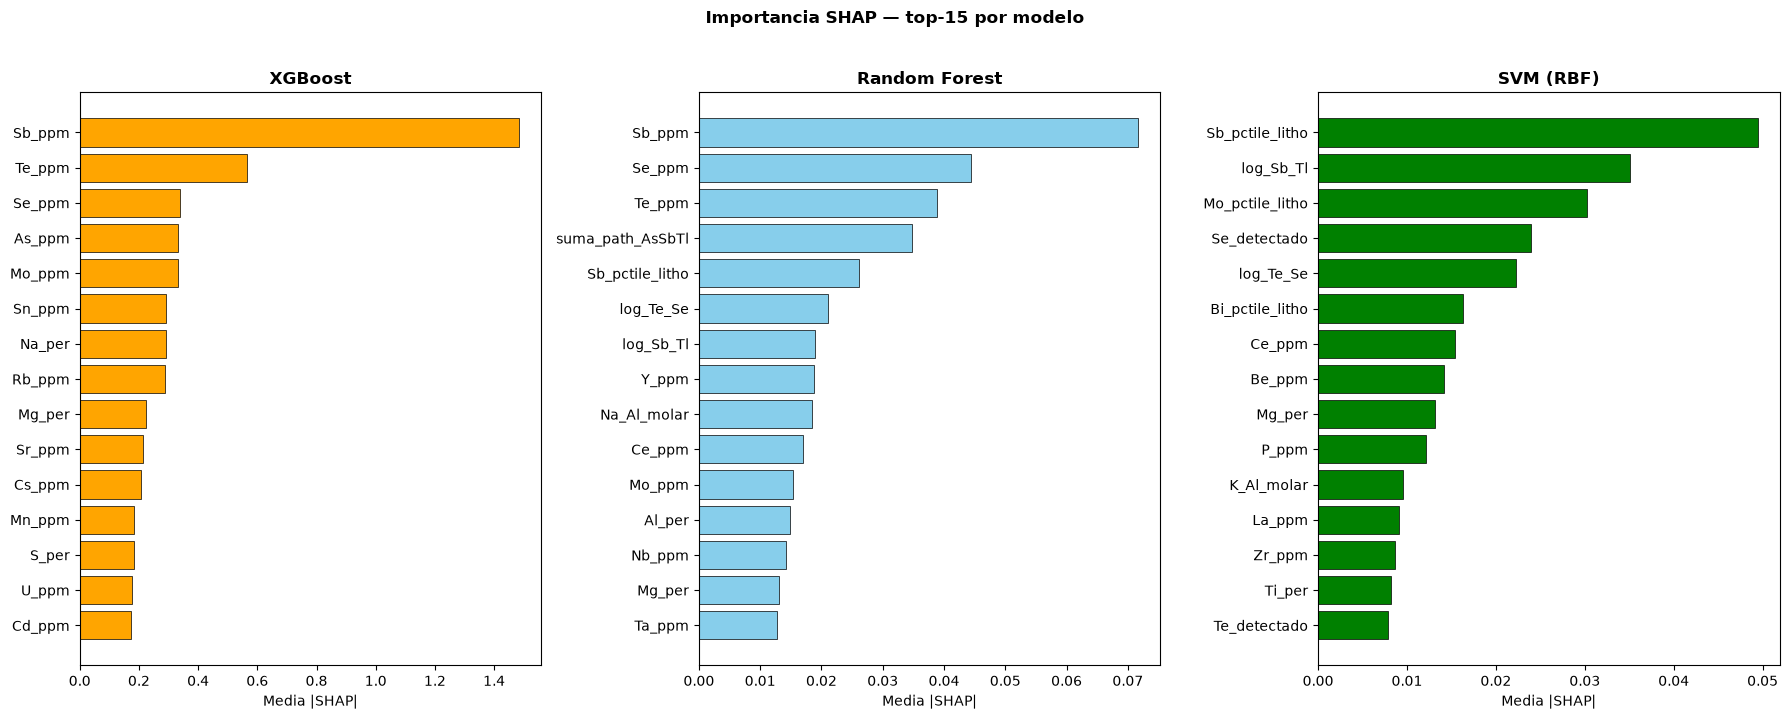

Comparación SHAP guardada.


In [8]:
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 7), sharey=False)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    r = shap_results[m]
    top15 = r['imp_df'].head(15)
    ax.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1],
            color=color, edgecolor='black', lw=0.5)
    ax.set_xlabel('Media |SHAP|')
    ax.set_title(f'{m}', fontweight='bold')
plt.suptitle('Importancia SHAP — top-15 por modelo', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/shap_bar_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparación SHAP guardada.')

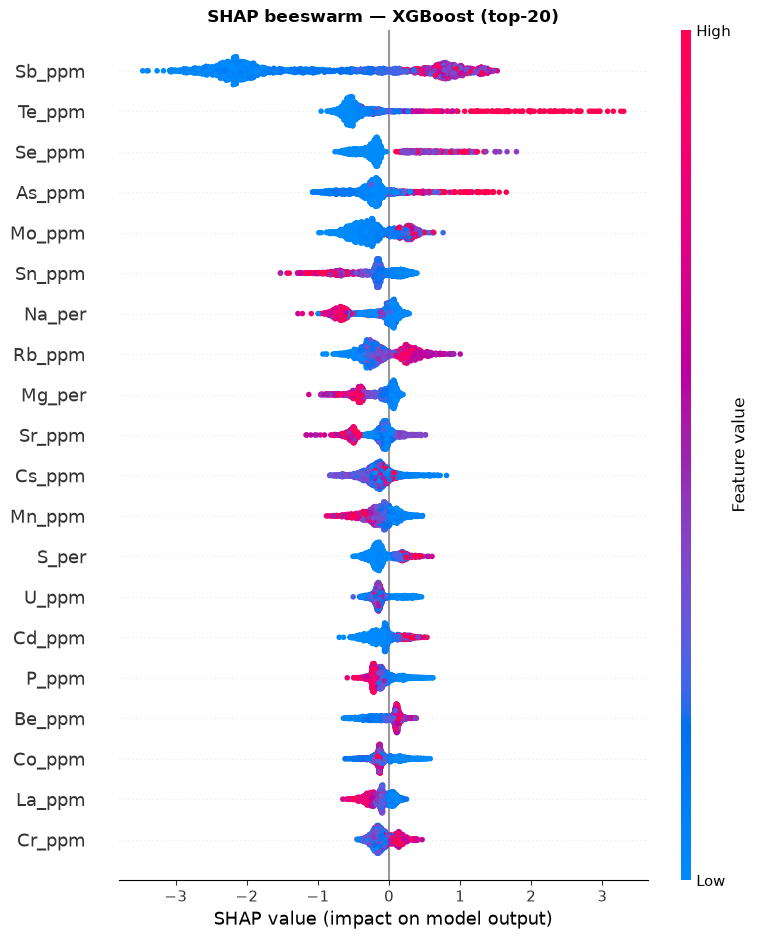

In [9]:
# Beeswarm del modelo líder (mayor F2_CV en S2)
m0 = TOP_3[0]
r0 = shap_results[m0]
plt.figure(figsize=(10, 8))
shap.summary_plot(r0['sv'], r0['Xtr'], max_display=20, show=False)
plt.title(f'SHAP beeswarm — {m0} (top-20)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

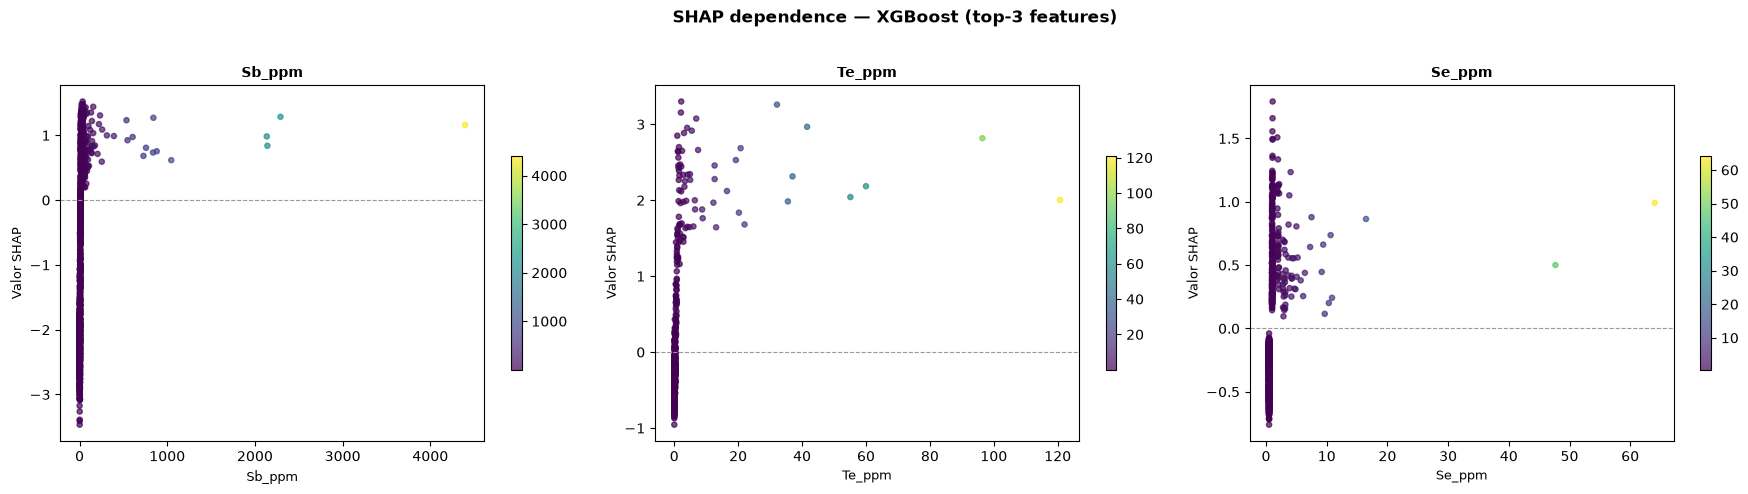

In [10]:
# Dependence plots — top-3 features del modelo líder
top3_feats = r0['imp_ser'].index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for i, feat in enumerate(top3_feats):
    j = r0['feats'].index(feat)
    xvals = r0['Xtr'][feat].values
    yvals = r0['sv'][:, j]
    sc = axes[i].scatter(xvals, yvals, c=xvals, cmap='viridis', s=14, alpha=0.7)
    axes[i].axhline(0, color='0.6', lw=0.8, ls='--')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Valor SHAP', fontsize=9)
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    plt.colorbar(sc, ax=axes[i], shrink=0.6)
plt.suptitle(f'SHAP dependence — {m0} (top-3 features)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()

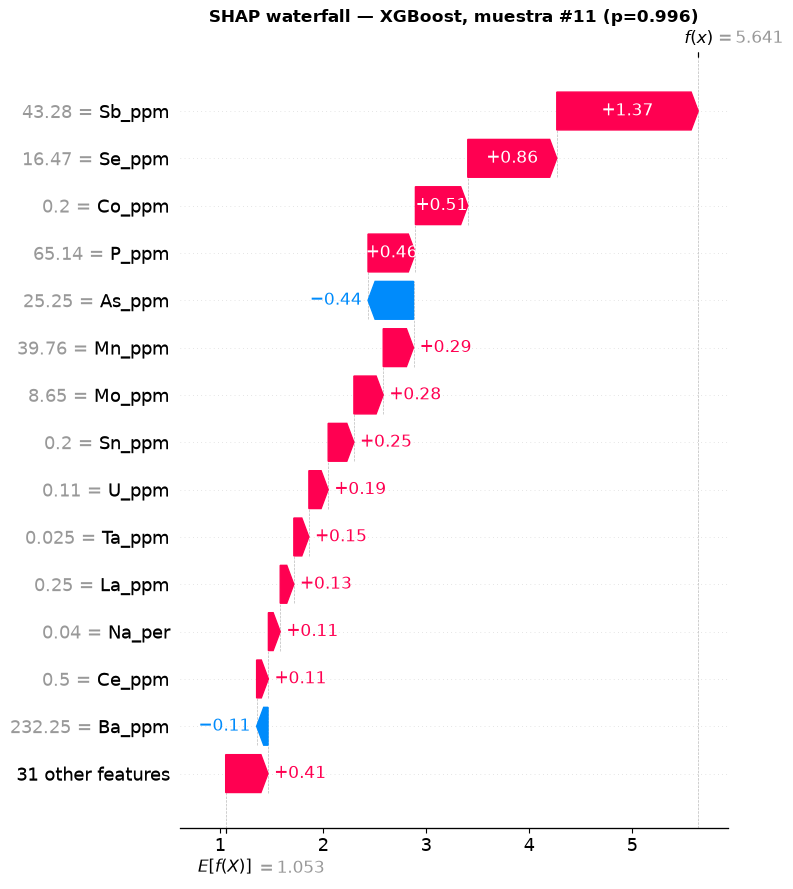

In [11]:
# Waterfall de un ejemplo positivo bien puntuado
m0 = TOP_3[0]
r0 = shap_results[m0]
n_shap = len(r0['sv'])
# Predecir probabilidades sobre la submuestra SHAP
if m0 in TREE_MODELS:
    proba_shap = r0['clf'].predict_proba(r0['Xtr'])[:, 1]
else:
    proba_shap = np.array([r0['clf'].predict_proba(
        StandardScaler().fit(SETS_TR[TOP3_CONFIG[m0]['set']]).transform(r0['Xtr'])
    )[:, 1]]).flatten()

mask_pos = (y_train.values[:n_shap] == 1)
if mask_pos.any():
    idx_ej = int(np.where(mask_pos)[0][np.argmax(proba_shap[mask_pos])])
else:
    idx_ej = int(np.argmax(proba_shap))

expl = shap.Explanation(values=r0['sv'][idx_ej], base_values=r0['base_val'],
                        data=r0['Xtr'].iloc[idx_ej].values, feature_names=r0['feats'])
plt.figure()
shap.plots.waterfall(expl, max_display=15, show=False)
plt.title(f'SHAP waterfall — {m0}, muestra #{idx_ej} (p={proba_shap[idx_ej]:.3f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Selección de features (barrido CV sobre importancia SHAP)

Para cada modelo del top-3:
1. **Universo**: features que acumulan el 95 % del |SHAP|.
2. **Barrido CV**: se evalúa F2_CV para top-1, top-2, …, top-n (orden SHAP).
3. **Regla 1-SE**: se elige el subconjunto más parsimonioso cuyo F2_CV ≥ máximo − 1 SE.

De esta forma cada modelo retiene solo las features que maximizan su rendimiento.

In [12]:
sel_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    r = shap_results[m]
    Xtr_m = SETS_TR[cfg['set']]

    # Universo: features acumulando 95 % |SHAP|
    n_95 = int(np.searchsorted(r['imp_df']['cum_frac'].values, 0.95) + 1)
    n_95 = min(n_95, len(r['feats']))
    feats_95 = r['imp_df']['feature'].iloc[:n_95].tolist()

    print(f'\n── Selección: {m} (universo = {n_95} features) ──')
    t0 = time.time()

    rows = []
    for k in range(1, n_95 + 1):
        mu, sd = f2_cv(m, Xtr_m[feats_95[:k]], y_train, cfg['params'], cfg['balanceo'])
        rows.append({'n_features': k, 'f2_cv_mean': mu, 'f2_cv_std': sd})
    sweep = pd.DataFrame(rows)

    # Mejor k
    idx_best = int(sweep['f2_cv_mean'].idxmax())
    best_f2  = sweep.loc[idx_best, 'f2_cv_mean']
    best_se  = sweep.loc[idx_best, 'f2_cv_std'] / np.sqrt(5)

    # 1-SE: menor k con F2 >= best - 1 SE
    mask_1se = sweep['f2_cv_mean'] >= best_f2 - best_se
    idx_1se  = int(sweep.loc[mask_1se, 'n_features'].idxmin())
    n_opt    = int(sweep.loc[idx_1se, 'n_features'])
    set_s3   = feats_95[:n_opt]

    sel_results[m] = {
        'sweep': sweep, 'n_95': n_95, 'n_opt': n_opt,
        'set_s3': set_s3, 'f2_s3': float(sweep.loc[idx_1se, 'f2_cv_mean']),
        'f2_best': best_f2, 'f2_best_se': best_se,
    }
    slug = m.lower().replace(' ', '_').replace('(', '').replace(')', '')
    sweep.to_csv(f'{DIR_TAB}/seleccion_features_{slug}.csv', index=False)

    print(f'  Mejor F2_CV = {best_f2:.4f} con {sweep.loc[idx_best, "n_features"]} features')
    print(f'  1-SE: {n_opt} features → F2_CV = {sel_results[m]["f2_s3"]:.4f}')
    print(f'  Tiempo: {time.time()-t0:.1f}s')


── Selección: XGBoost (universo = 36 features) ──
  Mejor F2_CV = 0.7324 con 33 features
  1-SE: 28 features → F2_CV = 0.7296
  Tiempo: 135.3s

── Selección: Random Forest (universo = 48 features) ──
  Mejor F2_CV = 0.6979 con 43 features
  1-SE: 39 features → F2_CV = 0.6916
  Tiempo: 196.2s

── Selección: SVM (RBF) (universo = 33 features) ──
  Mejor F2_CV = 0.6861 con 12 features
  1-SE: 8 features → F2_CV = 0.6718
  Tiempo: 86.6s


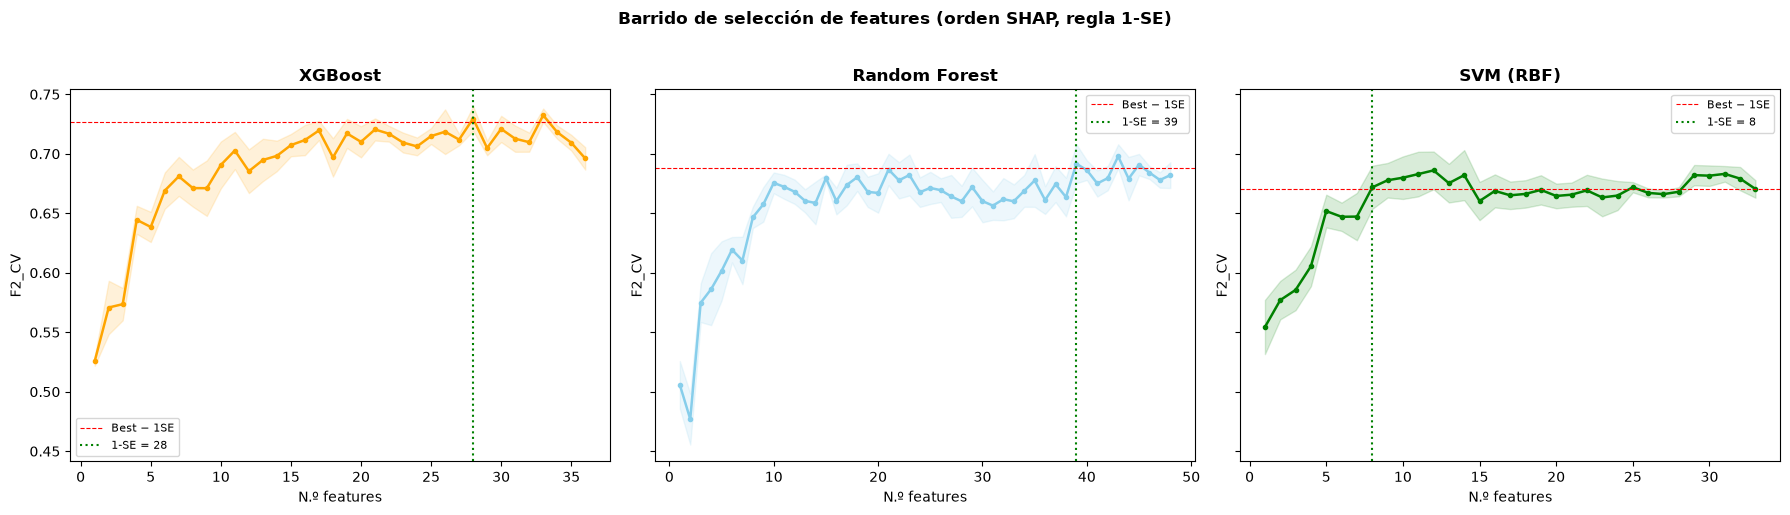

In [13]:
# Gráfico del barrido de selección
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    sr = sel_results[m]
    sw = sr['sweep']
    ax.plot(sw['n_features'], sw['f2_cv_mean'], color=color, lw=1.8, marker='o', ms=3)
    ax.fill_between(sw['n_features'],
                    sw['f2_cv_mean'] - sw['f2_cv_std']/np.sqrt(5),
                    sw['f2_cv_mean'] + sw['f2_cv_std']/np.sqrt(5),
                    alpha=0.15, color=color)
    ax.axhline(sr['f2_best'] - sr['f2_best_se'], ls='--', color='red', lw=0.8, label='Best − 1SE')
    ax.axvline(sr['n_opt'], ls=':', color='green', lw=1.5, label=f'1-SE = {sr["n_opt"]}')
    ax.set_xlabel('N.º features'); ax.set_ylabel('F2_CV')
    ax.set_title(f'{m}', fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Barrido de selección de features (orden SHAP, regla 1-SE)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/seleccion_features.png', dpi=150, bbox_inches='tight')
plt.show()

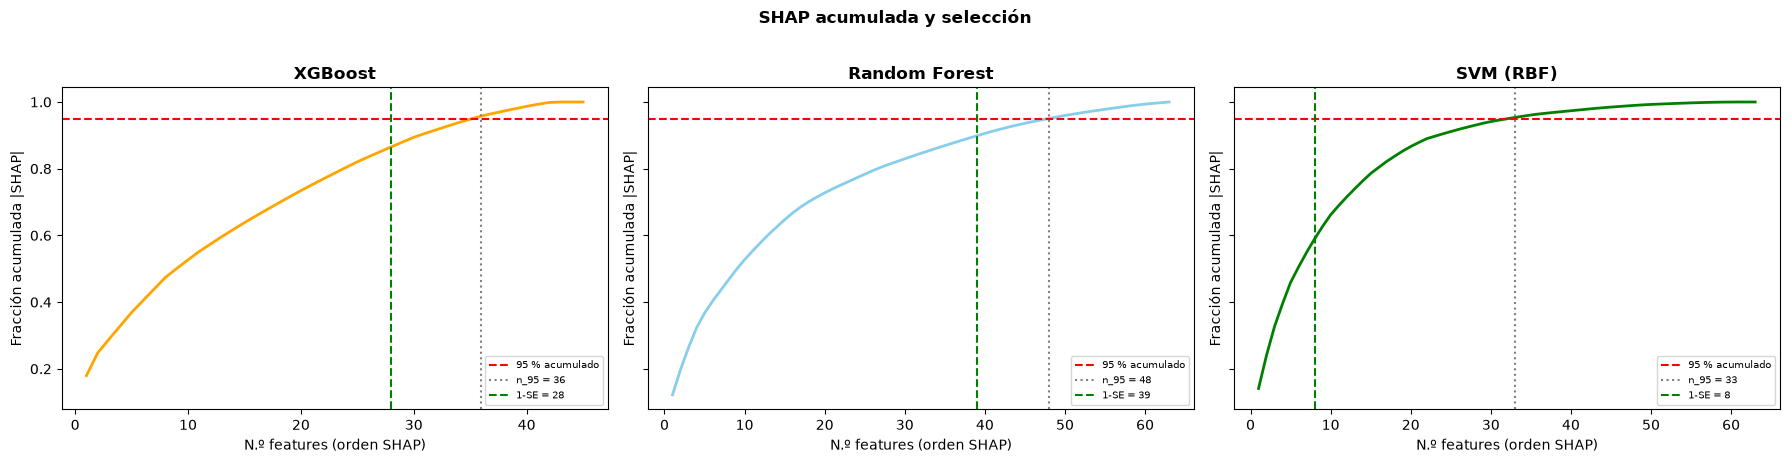

In [14]:
# SHAP acumulada con corte 95 % y punto 1-SE
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 4.5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    r = shap_results[m]
    sr = sel_results[m]
    ax.plot(range(1, len(r['imp_df'])+1), r['imp_df']['cum_frac'].values, color=color, lw=2)
    ax.axhline(0.95, ls='--', color='red', label='95 % acumulado')
    ax.axvline(sr['n_95'], ls=':', color='gray', label=f'n_95 = {sr["n_95"]}')
    ax.axvline(sr['n_opt'], ls='--', color='green', label=f'1-SE = {sr["n_opt"]}')
    ax.set_xlabel('N.º features (orden SHAP)')
    ax.set_ylabel('Fracción acumulada |SHAP|')
    ax.set_title(m, fontweight='bold'); ax.legend(fontsize=7)
plt.suptitle('SHAP acumulada y selección', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/shap_acumulada.png', dpi=150, bbox_inches='tight')
plt.show()

## Re-Optuna sobre features seleccionadas

Se re-optimizan los hiperparámetros de cada modelo sobre su set reducido (1-SE).
El espacio incluye **`use_class_weight`** (pesos de clase internos, coexisten con el oversampler) y parámetros
de regularización:

| Modelo | Parámetros clave |
|---|---|
| XGBoost | `learning_rate`, `n_estimators`, `max_depth`, `subsample`, `reg_alpha`, `reg_lambda`, `min_child_weight` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` |
| SVM (RBF) | `C`, `gamma` |

Se ejecutan **50 trials** por modelo con `TPESampler(seed=SEED)`.  Se conserva la
configuración (S2 o S3) que dé mayor F2_CV.

In [15]:
def espacio_optuna_s3(mod, trial):
    p = {}
    p['use_class_weight'] = trial.suggest_categorical('use_class_weight', [True, False])
    if mod == 'XGBoost':
        p['n_estimators']     = trial.suggest_int('n_estimators', 50, 500)
        p['max_depth']        = trial.suggest_int('max_depth', 3, 10)
        p['learning_rate']    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        p['subsample']        = trial.suggest_float('subsample', 0.5, 1.0)
        p['colsample_bytree'] = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        p['reg_alpha']        = trial.suggest_float('reg_alpha', 0.0, 10.0)
        p['reg_lambda']       = trial.suggest_float('reg_lambda', 0.0, 10.0)
        p['min_child_weight'] = trial.suggest_int('min_child_weight', 1, 10)
    elif mod == 'Random Forest':
        p['n_estimators']     = trial.suggest_int('n_estimators', 50, 500)
        p['max_depth']        = trial.suggest_int('max_depth', 3, 25)
        p['min_samples_leaf'] = trial.suggest_int('min_samples_leaf', 1, 15)
        p['min_samples_split']= trial.suggest_int('min_samples_split', 2, 15)
        p['max_features']     = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    elif mod == 'SVM (RBF)':
        p['C']     = trial.suggest_float('C', 0.01, 100.0, log=True)
        p['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    return p

optuna_results = {}
for m in TOP_3:
    cfg  = TOP3_CONFIG[m]
    sr   = sel_results[m]
    Xtr_sel = SETS_TR[cfg['set']][sr['set_s3']]
    bal  = cfg['balanceo']

    print(f'\n── Re-Optuna: {m} ({sr["n_opt"]} features, {N_TRIALS} trials) ──')
    t0 = time.time()

    # F2 con params fijos del S2 sobre features seleccionadas
    f2_fijos, _ = f2_cv(m, Xtr_sel, y_train, cfg['params'], bal)

    def objective(trial, _mod=m, _X=Xtr_sel, _bal=bal):
        params = espacio_optuna_s3(_mod, trial)
        f2, _ = f2_cv(_mod, _X, y_train, params, _bal)
        return f2

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    f2_optuna = study.best_value
    best_params = study.best_params

    # Elegir mejor configuración
    if f2_optuna > f2_fijos + 0.001:
        params_s3 = best_params
        f2_s3     = f2_optuna
        origen    = 'Optuna S3'
    else:
        params_s3 = cfg['params']
        f2_s3     = f2_fijos
        origen    = 'Params S2'

    optuna_results[m] = {
        'study': study, 'f2_fijos': f2_fijos, 'f2_optuna': f2_optuna,
        'best_params': best_params, 'params_s3': params_s3,
        'f2_s3': f2_s3, 'origen': origen,
    }
    print(f'  F2_CV (params S2): {f2_fijos:.4f}')
    print(f'  F2_CV (Optuna S3): {f2_optuna:.4f}  (best_trial #{study.best_trial.number})')
    print(f'  → Elegido: {origen}  F2_CV = {f2_s3:.4f}')
    print(f'  Tiempo: {time.time()-t0:.1f}s')


── Re-Optuna: XGBoost (28 features, 50 trials) ──
  F2_CV (params S2): 0.7296
  F2_CV (Optuna S3): 0.7308  (best_trial #7)
  → Elegido: Optuna S3  F2_CV = 0.7308
  Tiempo: 95.2s

── Re-Optuna: Random Forest (39 features, 50 trials) ──
  F2_CV (params S2): 0.6916
  F2_CV (Optuna S3): 0.7026  (best_trial #48)
  → Elegido: Optuna S3  F2_CV = 0.7026
  Tiempo: 455.7s

── Re-Optuna: SVM (RBF) (8 features, 50 trials) ──
  F2_CV (params S2): 0.6718
  F2_CV (Optuna S3): 0.6764  (best_trial #42)
  → Elegido: Optuna S3  F2_CV = 0.6764
  Tiempo: 113.6s


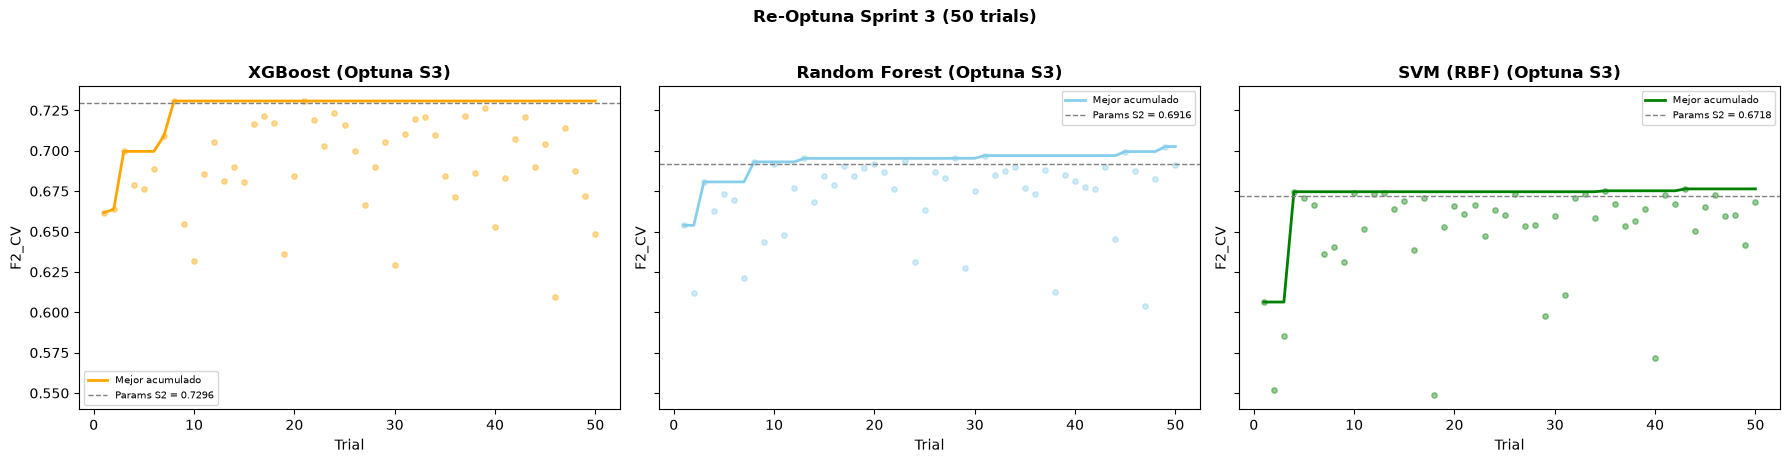

In [16]:
# Historial de optimización
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 4.5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    opr = optuna_results[m]
    vals = [t.value for t in opr['study'].trials if t.value is not None]
    best_run = np.maximum.accumulate(vals)
    ax.scatter(range(1, len(vals)+1), vals, s=15, alpha=0.4, color=color)
    ax.plot(range(1, len(vals)+1), best_run, lw=2, color=color, label='Mejor acumulado')
    ax.axhline(opr['f2_fijos'], ls='--', color='gray', lw=1, label=f'Params S2 = {opr["f2_fijos"]:.4f}')
    ax.set_xlabel('Trial'); ax.set_ylabel('F2_CV')
    ax.set_title(f'{m} ({opr["origen"]})', fontweight='bold'); ax.legend(fontsize=7)
plt.suptitle(f'Re-Optuna Sprint 3 ({N_TRIALS} trials)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/optuna_s3_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Exportar params
optuna_export = {}
for m in TOP_3:
    opr = optuna_results[m]
    optuna_export[m] = {
        'f2_cv_optuna': round(opr['f2_optuna'], 4),
        'f2_cv_fijos_s2': round(opr['f2_fijos'], 4),
        'params_elegidos': opr['params_s3'],
        'origen': opr['origen'],
    }
with open(f'{DIR_TAB}/optuna_s3_params.json', 'w') as f:
    json.dump(optuna_export, f, indent=2, ensure_ascii=False)
print('Params de Optuna S3 exportados.')

Params de Optuna S3 exportados.


## Curvas de aprendizaje (diagnóstico de sesgo/varianza)

Se comparan las curvas de aprendizaje **antes** (params S2) y **después** (params S3) de la re-optimización, sobre el set 1-SE de cada modelo.  La brecha train-validación (gap) cuantifica el sobreajuste: un gap menor indica mejor generalización.

In [18]:
train_sizes_frac = np.linspace(0.1, 1.0, 8)
lc_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr  = sel_results[m]
    opr = optuna_results[m]
    Xtr_sel = SETS_TR[cfg['set']][sr['set_s3']]

    # Pre: params S2
    pipe_pre = make_pipe(m, cfg['params'], cfg['balanceo'])
    sizes_pre, tr_pre, va_pre = learning_curve(
        pipe_pre, Xtr_sel, y_train, cv=CV5, scoring=F2_SCORER,
        train_sizes=train_sizes_frac, n_jobs=-1, shuffle=True, random_state=SEED)
    gap_pre = float((tr_pre.mean(1) - va_pre.mean(1))[-1])

    # Post: params S3
    pipe_post = make_pipe(m, opr['params_s3'], cfg['balanceo'])
    sizes_post, tr_post, va_post = learning_curve(
        pipe_post, Xtr_sel, y_train, cv=CV5, scoring=F2_SCORER,
        train_sizes=train_sizes_frac, n_jobs=-1, shuffle=True, random_state=SEED)
    gap_post = float((tr_post.mean(1) - va_post.mean(1))[-1])

    lc_results[m] = {
        'sizes_pre': sizes_pre, 'tr_pre': tr_pre, 'va_pre': va_pre, 'gap_pre': gap_pre,
        'sizes_post': sizes_post, 'tr_post': tr_post, 'va_post': va_post, 'gap_post': gap_post,
    }
    # Guardar CSV
    slug = m.lower().replace(' ', '_').replace('(', '').replace(')', '')
    lc_df = pd.DataFrame({
        'train_size': sizes_pre,
        'train_pre': tr_pre.mean(1), 'val_pre': va_pre.mean(1),
        'train_post': tr_post.mean(1), 'val_post': va_post.mean(1),
    })
    lc_df.to_csv(f'{DIR_TAB}/learning_curves_{slug}.csv', index=False)
    print(f'{m}: gap_pre={gap_pre:.3f} → gap_post={gap_post:.3f}  '
          f'({"↓ MEJOR" if gap_post < gap_pre else "↑ peor"})')

XGBoost: gap_pre=0.275 → gap_post=0.242  (↓ MEJOR)
Random Forest: gap_pre=0.238 → gap_post=0.193  (↓ MEJOR)
SVM (RBF): gap_pre=0.040 → gap_post=0.029  (↓ MEJOR)


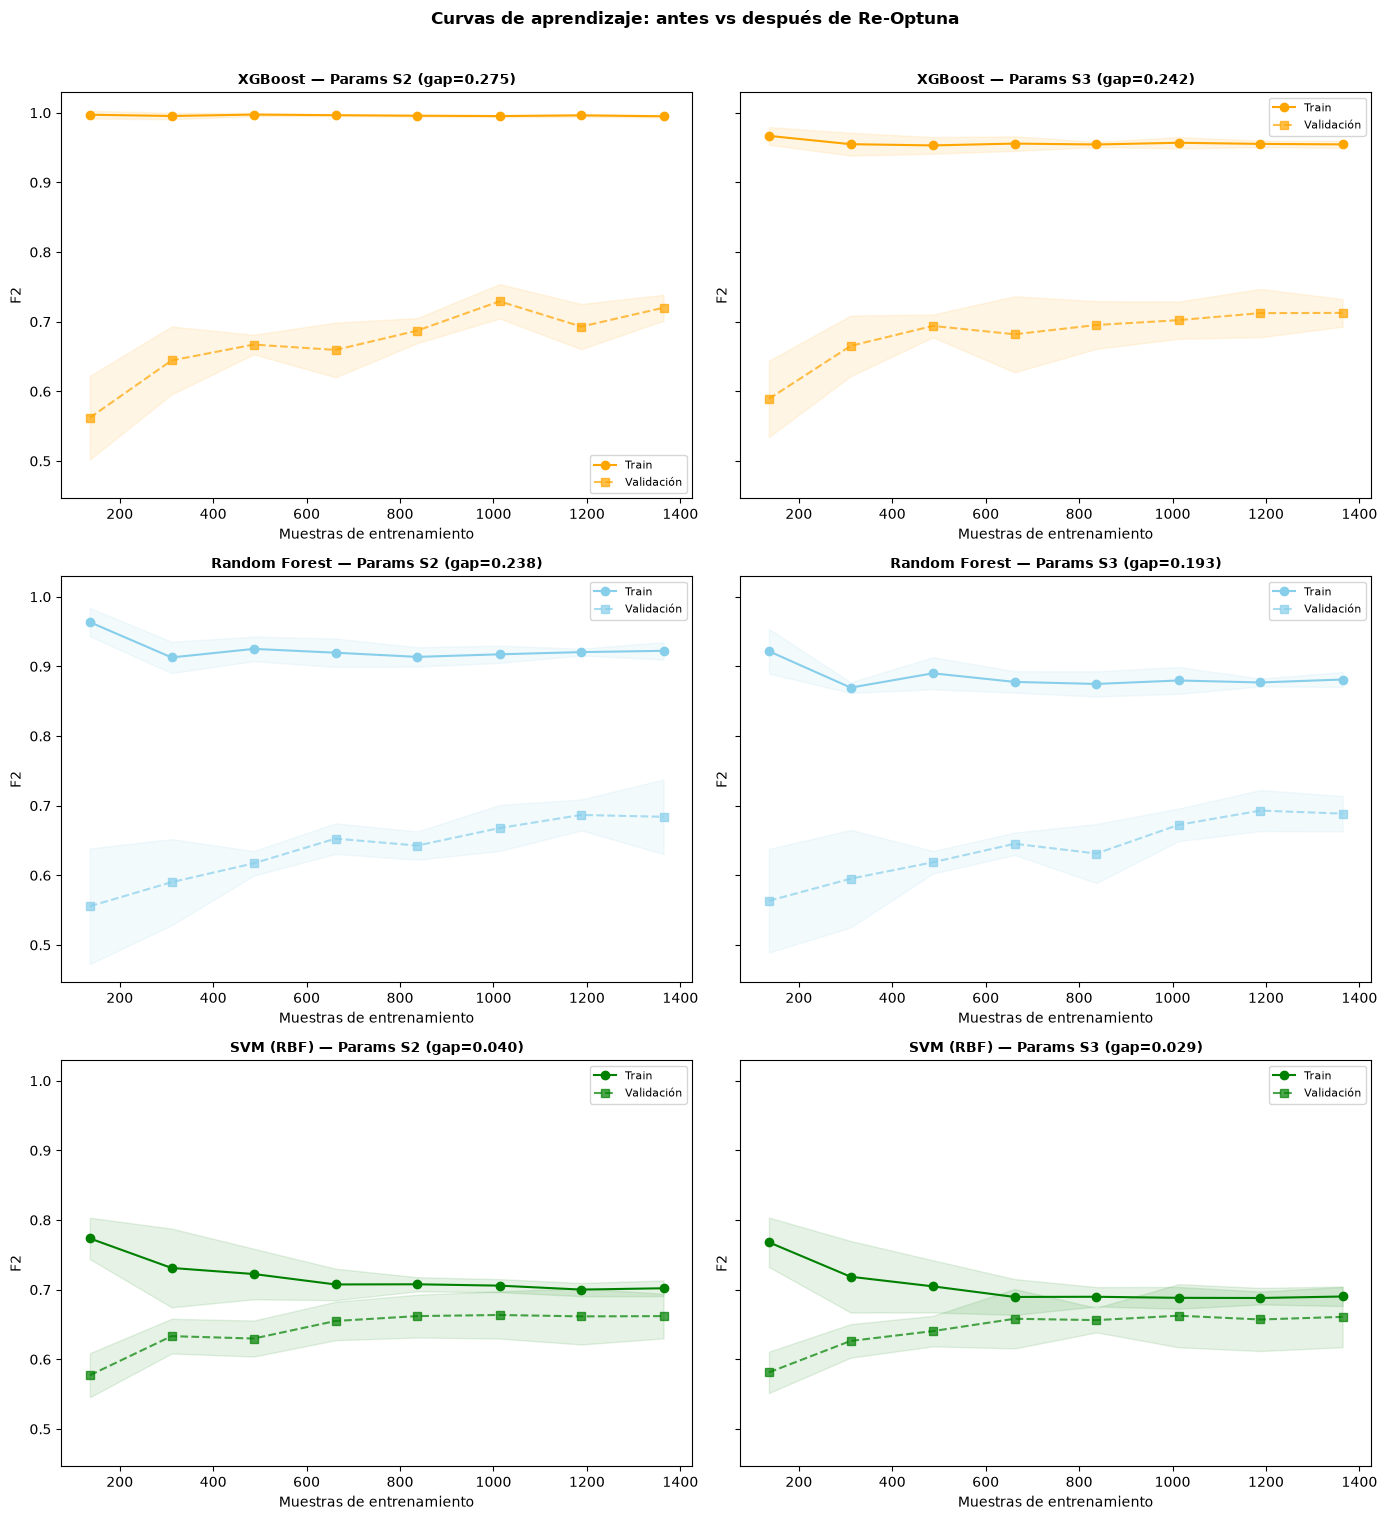

In [19]:
fig, axes = plt.subplots(len(TOP_3), 2, figsize=(14, 5*len(TOP_3)), sharey=True)
colores = ['orange', 'skyblue', 'green']
for row, (m, color) in enumerate(zip(TOP_3, colores)):
    lc = lc_results[m]
    for col, (sizes, tr, va, gap, tit) in enumerate([
        (lc['sizes_pre'], lc['tr_pre'], lc['va_pre'], lc['gap_pre'],
         f'Params S2 (gap={lc["gap_pre"]:.3f})'),
        (lc['sizes_post'], lc['tr_post'], lc['va_post'], lc['gap_post'],
         f'Params S3 (gap={lc["gap_post"]:.3f})'),
    ]):
        ax = axes[row, col] if len(TOP_3) > 1 else axes[col]
        ax.plot(sizes, tr.mean(1), 'o-', color=color, label='Train')
        ax.fill_between(sizes, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1),
                        alpha=0.1, color=color)
        ax.plot(sizes, va.mean(1), 's--', color=color, label='Validación', alpha=0.7)
        ax.fill_between(sizes, va.mean(1)-va.std(1), va.mean(1)+va.std(1),
                        alpha=0.1, color=color)
        ax.set_xlabel('Muestras de entrenamiento')
        ax.set_ylabel('F2')
        ax.set_title(f'{m} — {tit}', fontweight='bold', fontsize=10)
        ax.legend(fontsize=8)
plt.suptitle('Curvas de aprendizaje: antes vs después de Re-Optuna',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/learning_curves_s3_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibración y ajuste de umbral

Para cada modelo se computan probabilidades **OOF** (out-of-fold) en tres variantes:
- Sin calibrar
- Sigmoide (Platt scaling)
- Isotónica

Se elige el método con menor Brier score OOF.  El **umbral de decisión se optimiza dentro de cada fold** (anidado, criterio máx F2), reportando media ± std.

> **Umbral anidado vs global:** optimizar el umbral sobre el OOF concatenado sería usar el mismo dato para ajustar y evaluar.  El enfoque anidado (un umbral por fold) produce una estimación honesta de la variabilidad del punto de operación.

In [20]:
cal_results = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr  = sel_results[m]
    opr = optuna_results[m]
    params_s3 = opr['params_s3']
    bal  = cfg['balanceo']
    Xtr_sel = SETS_TR[cfg['set']][sr['set_s3']]

    print(f'\n── Calibración + umbral: {m} ──')

    oof_uncal = np.zeros(len(y_train))
    oof_sig   = np.zeros(len(y_train))
    oof_iso   = np.zeros(len(y_train))
    thr_uncal, thr_sig, thr_iso = [], [], []

    for tr_idx, va_idx in CV5.split(Xtr_sel, y_train):
        # Base sin calibrar
        pipe = make_pipe(m, params_s3, bal)
        pipe.fit(Xtr_sel.iloc[tr_idx], y_train.iloc[tr_idx])
        p_uncal = pipe.predict_proba(Xtr_sel.iloc[va_idx])[:, 1]
        oof_uncal[va_idx] = p_uncal

        # Sigmoide
        cal_s = CalibratedClassifierCV(make_pipe(m, params_s3, bal), method='sigmoid', cv=3)
        cal_s.fit(Xtr_sel.iloc[tr_idx], y_train.iloc[tr_idx])
        p_sig = cal_s.predict_proba(Xtr_sel.iloc[va_idx])[:, 1]
        oof_sig[va_idx] = p_sig

        # Isotónica
        cal_i = CalibratedClassifierCV(make_pipe(m, params_s3, bal), method='isotonic', cv=3)
        cal_i.fit(Xtr_sel.iloc[tr_idx], y_train.iloc[tr_idx])
        p_iso = cal_i.predict_proba(Xtr_sel.iloc[va_idx])[:, 1]
        oof_iso[va_idx] = p_iso

        # Umbrales anidados (max F2 en cada fold)
        y_va = y_train.iloc[va_idx]
        thr_uncal.append(threshold_optimo_f2(y_va, p_uncal)[0])
        thr_sig.append(threshold_optimo_f2(y_va, p_sig)[0])
        thr_iso.append(threshold_optimo_f2(y_va, p_iso)[0])

    # Elegir calibración por Brier score
    brier_u = brier_score_loss(y_train, oof_uncal)
    brier_s = brier_score_loss(y_train, oof_sig)
    brier_i = brier_score_loss(y_train, oof_iso)

    opciones = [
        ('Sin calibrar', brier_u, oof_uncal, thr_uncal),
        ('Sigmoide',     brier_s, oof_sig,   thr_sig),
        ('Isotónica',    brier_i, oof_iso,   thr_iso),
    ]
    mejor = min(opciones, key=lambda x: x[1])
    metodo_cal = mejor[0]
    oof_cal    = mejor[2]
    umbral     = float(np.mean(mejor[3]))
    umbral_std = float(np.std(mejor[3]))

    # F2 OOF
    y_oof_pred = (oof_cal >= umbral).astype(int)
    f2_oof = float(fbeta_score(y_train, y_oof_pred, beta=2))

    cal_results[m] = {
        'metodo_cal': metodo_cal, 'oof_cal': oof_cal,
        'oof_uncal': oof_uncal, 'oof_sig': oof_sig, 'oof_iso': oof_iso,
        'brier_u': brier_u, 'brier_s': brier_s, 'brier_i': brier_i,
        'umbral': umbral, 'umbral_std': umbral_std,
        'umbrales_fold': mejor[3],
        'f2_oof': f2_oof,
    }
    print(f'  Brier: sin_cal={brier_u:.4f}, sig={brier_s:.4f}, iso={brier_i:.4f} → {metodo_cal}')
    print(f'  Umbral anidado: {umbral:.3f} ± {umbral_std:.3f}')
    print(f'  F2_OOF (umbral medio): {f2_oof:.4f}')


── Calibración + umbral: XGBoost ──
  Brier: sin_cal=0.0978, sig=0.0652, iso=0.0635 → Isotónica
  Umbral anidado: 0.163 ± 0.042
  F2_OOF (umbral medio): 0.7103

── Calibración + umbral: Random Forest ──
  Brier: sin_cal=0.0887, sig=0.0660, iso=0.0658 → Isotónica
  Umbral anidado: 0.188 ± 0.063
  F2_OOF (umbral medio): 0.6935

── Calibración + umbral: SVM (RBF) ──
  Brier: sin_cal=0.1324, sig=0.0771, iso=0.0779 → Sigmoide
  Umbral anidado: 0.164 ± 0.029
  F2_OOF (umbral medio): 0.6662


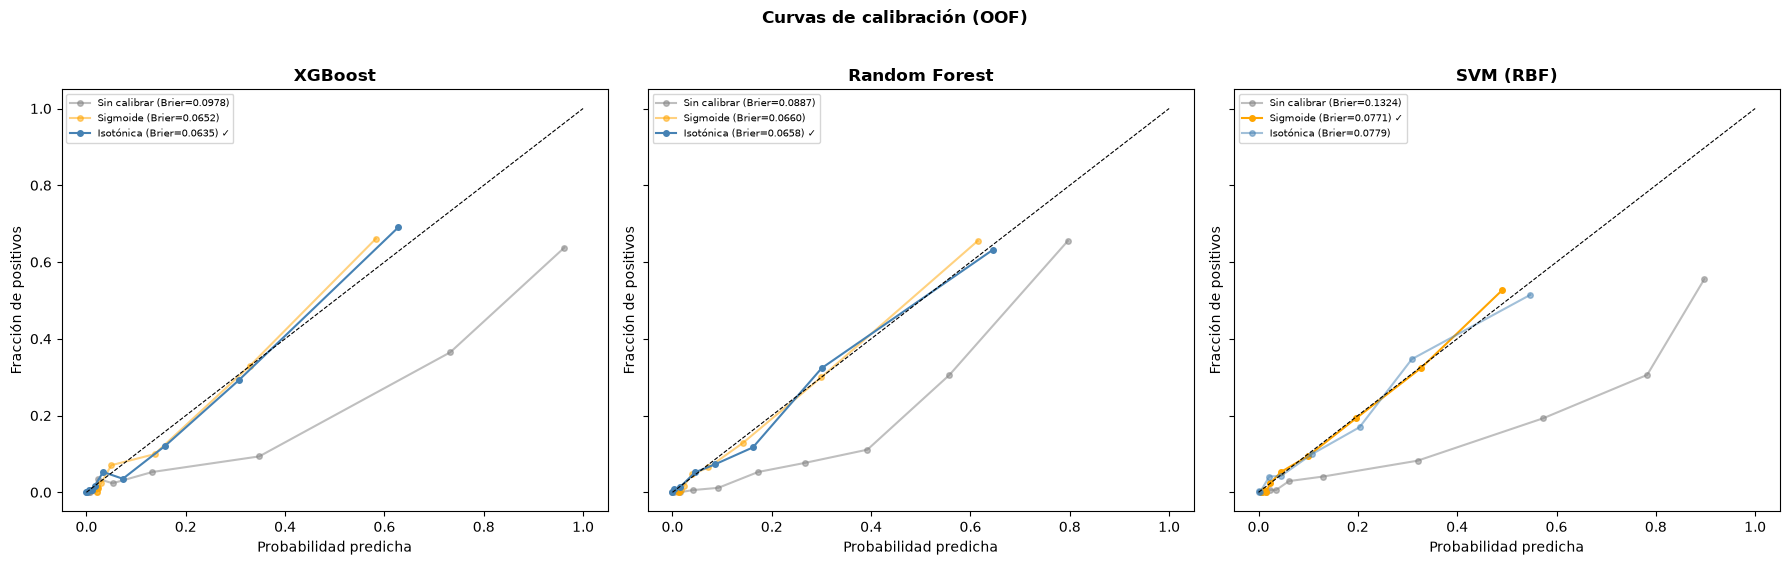

In [21]:
# Curvas de calibración (reliability)
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 5.5), sharey=True)
for ax, m in zip(axes, TOP_3):
    cr = cal_results[m]
    for probs, nombre, col in [(cr['oof_uncal'], 'Sin calibrar', 'gray'),
                               (cr['oof_sig'],   'Sigmoide',     'orange'),
                               (cr['oof_iso'],   'Isotónica',    'steelblue')]:
        fx, fy = calibration_curve(y_train, probs, n_bins=10, strategy='quantile')
        lbl = f'{nombre} (Brier={brier_score_loss(y_train, probs):.4f})'
        if nombre == cr['metodo_cal']:
            lbl += ' ✓'
        ax.plot(fy, fx, 'o-', label=lbl, lw=1.5, ms=4,
                color=col, alpha=1.0 if nombre == cr['metodo_cal'] else 0.5)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Fracción de positivos')
    ax.set_title(m, fontweight='bold'); ax.legend(fontsize=7)
plt.suptitle('Curvas de calibración (OOF)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/calibracion.png', dpi=150, bbox_inches='tight')
plt.show()

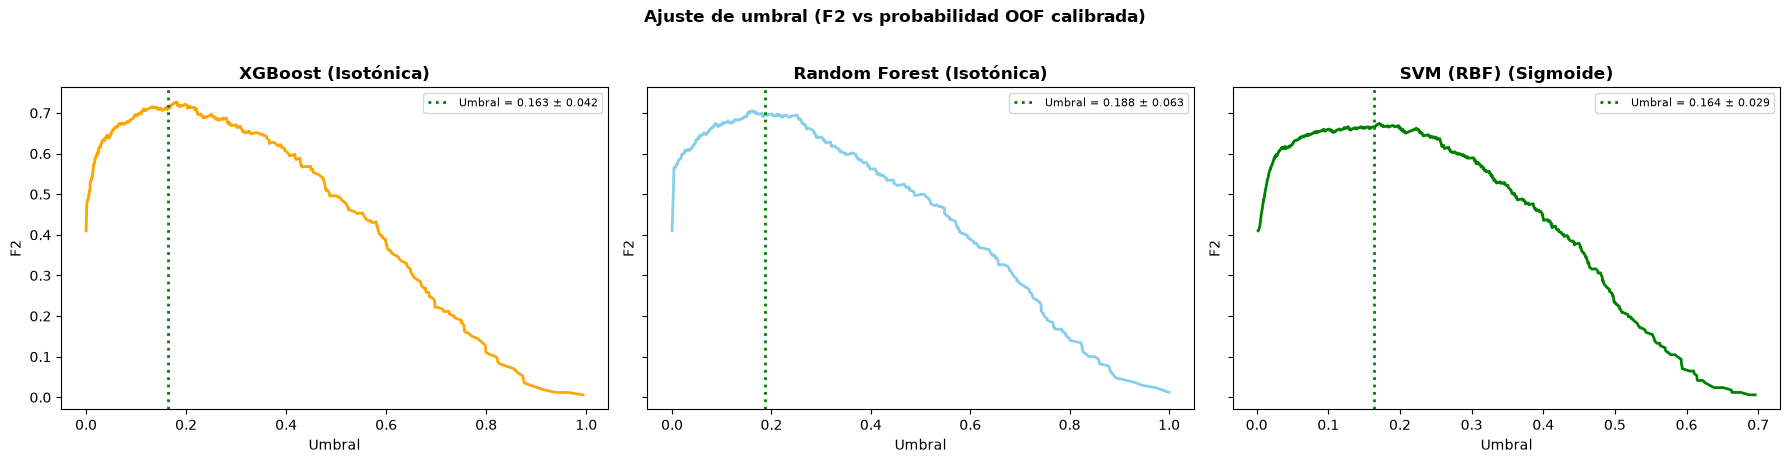

In [22]:
# Umbral F2 vs probabilidad OOF calibrada
fig, axes = plt.subplots(1, len(TOP_3), figsize=(6*len(TOP_3), 4.5), sharey=True)
colores = ['orange', 'skyblue', 'green']
for ax, m, color in zip(axes, TOP_3, colores):
    cr = cal_results[m]
    prec, rec, thr = precision_recall_curve(y_train, cr['oof_cal'])
    f2g = (5*prec*rec) / (4*prec + rec + 1e-12)
    ax.plot(thr, f2g[:-1], color=color, lw=2)
    ax.axvline(cr['umbral'], ls=':', color='green', lw=2,
               label=f'Umbral = {cr["umbral"]:.3f} ± {cr["umbral_std"]:.3f}')
    ax.set_xlabel('Umbral'); ax.set_ylabel('F2')
    ax.set_title(f'{m} ({cr["metodo_cal"]})', fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Ajuste de umbral (F2 vs probabilidad OOF calibrada)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/ajuste_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

## Selección del campeón

Se comparan los tres modelos tras el pipeline completo (1-SE + Re-Optuna + calibración + umbral anidado) y se elige el de **mayor F2_CV** como campeón del Sprint 3.

In [23]:
resumen_top3 = []
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr  = sel_results[m]
    opr = optuna_results[m]
    cr  = cal_results[m]
    resumen_top3.append({
        'Modelo': m, 'Familia': cfg['familia'],
        'Set S2': cfg['set'], 'Features S2': len(SETS_TR[cfg['set']].columns),
        'Features S3 (1-SE)': sr['n_opt'],
        'F2_CV S2': cfg['f2_cv'],
        'F2_CV S3 (re-Optuna)': opr['f2_s3'],
        'Origen params': opr['origen'],
        'Calibración': cr['metodo_cal'],
        'Umbral': cr['umbral'],
        'F2_OOF': cr['f2_oof'],
    })
df_top3 = pd.DataFrame(resumen_top3)
df_top3.to_csv(f'{DIR_TAB}/comparativa_top3_s3.csv', index=False)

# Campeón
CAMPEON = df_top3.loc[df_top3['F2_CV S3 (re-Optuna)'].idxmax(), 'Modelo']
F2_CAMPEON = optuna_results[CAMPEON]['f2_s3']

print(f'\n{"="*60}')
print(f'CAMPEÓN Sprint 3: {CAMPEON}')
print(f'  F2_CV = {F2_CAMPEON:.4f}')
print(f'  Features: {sel_results[CAMPEON]["n_opt"]} (de {len(SETS_TR[TOP3_CONFIG[CAMPEON]["set"]].columns)})')
print(f'  Calibración: {cal_results[CAMPEON]["metodo_cal"]}')
print(f'  Umbral anidado: {cal_results[CAMPEON]["umbral"]:.3f} ± {cal_results[CAMPEON]["umbral_std"]:.3f}')
print(f'{"="*60}\n')

vmin = df_top3['F2_CV S3 (re-Optuna)'].min()
vmax = df_top3['F2_CV S3 (re-Optuna)'].max()
df_top3.style.applymap(lambda v: coral(v, vmin, vmax),
                       subset=['F2_CV S2', 'F2_CV S3 (re-Optuna)', 'F2_OOF']) \
    .format(precision=4).set_caption('Comparativa top-3 — Sprint 3')


CAMPEÓN Sprint 3: XGBoost
  F2_CV = 0.7308
  Features: 28 (de 45)
  Calibración: Isotónica
  Umbral anidado: 0.163 ± 0.042



,Modelo,Familia,Set S2,Features S2,Features S3 (1-SE),F2_CV S2,F2_CV S3 (re-Optuna),Origen params,Calibración,Umbral,F2_OOF
0,XGBoost,Boosting,E2 +Cluster,45,28,0.7258,0.7308,Optuna S3,Isotónica,0.1633,0.7103
1,Random Forest,Bagging/Árbol,E3 +Índ+Clust+Inter,63,39,0.6858,0.7026,Optuna S3,Isotónica,0.1877,0.6935
2,SVM (RBF),Lineal/Kernel,E3 +Índ+Clust+Inter,63,8,0.6797,0.6764,Optuna S3,Sigmoide,0.1636,0.6662


## Ablación de pathfinders principales

Se evalúa la contribución individual de **As, Sb, Te, Mo** — los pathfinders del halo geoquímico epitermal.  Para cada uno se eliminan **todas** las features derivadas (medición directa, índices compuestos, percentiles por cluster) y se mide la caída en F2_CV.

**Objetivo:** verificar que el modelo detecta la **firma conjunta del halo** y no depende críticamente de un solo elemento proxy.  Una caída severa (> 0.03) al quitar un solo elemento indicaría dependencia excesiva.

In [24]:
def features_del_elemento(elem, all_feats):
    # Retorna features que dependen del elemento dado
    result = []
    for f in all_feats:
        if f == f'{elem}_ppm' or f == f'{elem}_per':
            result.append(f); continue
        if f == f'{elem}_pctile_litho':
            result.append(f); continue
        if 'suma_path' in f and elem in f:
            result.append(f); continue
        if f.startswith('log_'):
            partes = f.replace('log_', '').split('_')
            if elem in partes:
                result.append(f); continue
    return result

PATHFINDERS_ABLACION = ['As', 'Sb', 'Te', 'Mo']
campeon_cfg  = TOP3_CONFIG[CAMPEON]
campeon_feats = sel_results[CAMPEON]['set_s3']
campeon_params = optuna_results[CAMPEON]['params_s3']
campeon_bal  = campeon_cfg['balanceo']
Xtr_campeon  = SETS_TR[campeon_cfg['set']][campeon_feats]
f2_base, _   = f2_cv(CAMPEON, Xtr_campeon, y_train, campeon_params, campeon_bal)

abl_rows = [{'Elemento': 'Baseline (todos)', 'Removidas': 0, 'Detalle': '-',
             'F2_CV': round(f2_base, 4), 'ΔF2': 0.0}]

for elem in PATHFINDERS_ABLACION:
    feats_elem = features_del_elemento(elem, campeon_feats)
    feats_sin  = [f for f in campeon_feats if f not in feats_elem]
    if not feats_elem:
        abl_rows.append({'Elemento': f'−{elem}', 'Removidas': 0,
                         'Detalle': '(no presente)', 'F2_CV': round(f2_base, 4), 'ΔF2': 0.0})
        continue
    f2_sin, _ = f2_cv(CAMPEON, SETS_TR[campeon_cfg['set']][feats_sin], y_train,
                       campeon_params, campeon_bal)
    abl_rows.append({'Elemento': f'−{elem}', 'Removidas': len(feats_elem),
                     'Detalle': ', '.join(feats_elem),
                     'F2_CV': round(f2_sin, 4), 'ΔF2': round(f2_sin - f2_base, 4)})

df_abl = pd.DataFrame(abl_rows)
df_abl.to_csv(f'{DIR_TAB}/ablacion_pathfinders.csv', index=False)

print('Ablación de pathfinders:')
for _, row in df_abl.iterrows():
    sev = ''
    if row['ΔF2'] < -0.03:
        sev = '  ← DEPENDENCIA FUERTE'
    elif row['ΔF2'] < -0.01:
        sev = '  ← dependencia moderada'
    print(f'  {row["Elemento"]:20s}  F2={row["F2_CV"]:.4f}  ΔF2={row["ΔF2"]:+.4f}{sev}')

# Interpretación
caidas = {r['Elemento']: r['ΔF2'] for _, r in df_abl.iterrows() if r['Elemento'] != 'Baseline (todos)'}
max_caida = min(caidas.values())
if max_caida > -0.01:
    interp = 'El modelo NO depende críticamente de ningún pathfinder individual → detecta la firma conjunta del halo.'
elif max_caida > -0.03:
    elem_dep = [k for k, v in caidas.items() if v < -0.01]
    interp = f'Dependencia moderada en {elem_dep}.  El modelo aún funciona sin ellos pero pierde rendimiento.'
else:
    elem_dep = [k for k, v in caidas.items() if v < -0.03]
    interp = f'DEPENDENCIA FUERTE en {elem_dep}.  Discutir como limitación: si el pathfinder no es muestreado, el modelo pierde capacidad.'
print(f'\n→ {interp}')

Ablación de pathfinders:
  Baseline (todos)      F2=0.7308  ΔF2=+0.0000
  −As                   F2=0.7277  ΔF2=-0.0031
  −Sb                   F2=0.6862  ΔF2=-0.0446  ← DEPENDENCIA FUERTE
  −Te                   F2=0.6861  ΔF2=-0.0447  ← DEPENDENCIA FUERTE
  −Mo                   F2=0.7397  ΔF2=+0.0089

→ DEPENDENCIA FUERTE en ['−Sb', '−Te'].  Discutir como limitación: si el pathfinder no es muestreado, el modelo pierde capacidad.


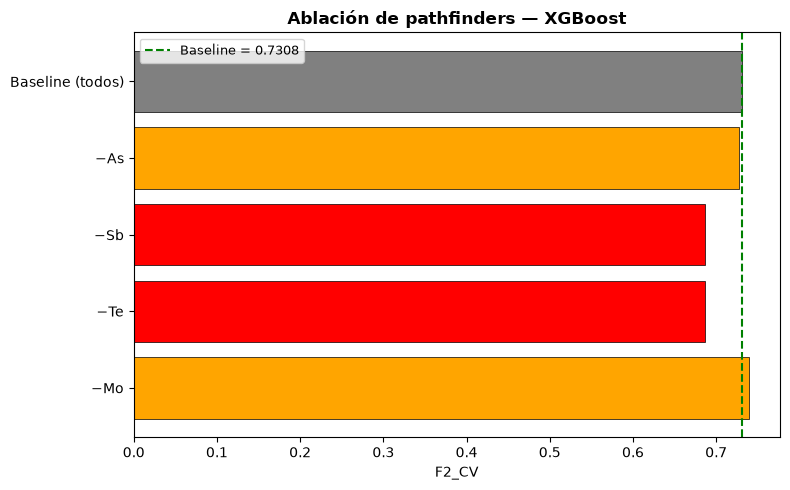

In [25]:
# Gráfico de ablación
fig, ax = plt.subplots(figsize=(8, 5))
colores_abl = ['gray'] + ['orange' if abs(r['ΔF2']) < 0.01 else
               'red' if r['ΔF2'] < -0.03 else 'orange'
               for _, r in df_abl.iloc[1:].iterrows()]
ax.barh(df_abl['Elemento'][::-1], df_abl['F2_CV'][::-1], color=colores_abl[::-1],
        edgecolor='black', lw=0.5)
ax.axvline(f2_base, ls='--', color='green', lw=1.5, label=f'Baseline = {f2_base:.4f}')
ax.set_xlabel('F2_CV')
ax.set_title(f'Ablación de pathfinders — {CAMPEON}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/ablacion_pathfinders.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluación hold-out (informativo)

Se entrena el pipeline calibrado del campeón sobre **todo** el train y se evalúa contra el hold-out una única vez.  Esta evaluación es **informativa** — la decisión de métricas se basa en F2_CV.

In [26]:
campeon_cal    = cal_results[CAMPEON]['metodo_cal']
campeon_umbral = cal_results[CAMPEON]['umbral']
campeon_params = optuna_results[CAMPEON]['params_s3']
campeon_bal    = TOP3_CONFIG[CAMPEON]['balanceo']
campeon_feats  = sel_results[CAMPEON]['set_s3']
Xtr_campeon    = SETS_TR[TOP3_CONFIG[CAMPEON]['set']][campeon_feats]
Xte_campeon    = SETS_TE[TOP3_CONFIG[CAMPEON]['set']][campeon_feats]

# Modelo final calibrado
if campeon_cal == 'Sin calibrar':
    modelo_final = make_pipe(CAMPEON, campeon_params, campeon_bal)
    modelo_final.fit(Xtr_campeon, y_train)
else:
    cal_method = 'sigmoid' if campeon_cal == 'Sigmoide' else 'isotonic'
    modelo_final = CalibratedClassifierCV(
        make_pipe(CAMPEON, campeon_params, campeon_bal),
        method=cal_method, cv=5)
    modelo_final.fit(Xtr_campeon, y_train)

joblib.dump(modelo_final, f'{DIR_MODELS}/modelo_campeon_s3.pkl')

# Hold-out
proba_ho = modelo_final.predict_proba(Xte_campeon)[:, 1]
y_pred_ho = (proba_ho >= campeon_umbral).astype(int)

metr_ho = {
    'F2':        float(fbeta_score(y_test, y_pred_ho, beta=2)),
    'Recall':    float(recall_score(y_test, y_pred_ho)),
    'Precision': float(precision_score(y_test, y_pred_ho, zero_division=0)),
    'F1':        float(f1_score(y_test, y_pred_ho)),
    'Accuracy':  float(accuracy_score(y_test, y_pred_ho)),
    'AUC-ROC':   float(roc_auc_score(y_test, proba_ho)),
    'AUC-PR':    float(average_precision_score(y_test, proba_ho)),
    'Brier':     float(brier_score_loss(y_test, proba_ho)),
}

print(f'Evaluación hold-out — {CAMPEON} (umbral = {campeon_umbral:.3f}):')
for k, v in metr_ho.items():
    print(f'  {k:12s}: {v:.4f}')

Evaluación hold-out — XGBoost (umbral = 0.163):
  F2          : 0.6891
  Recall      : 0.8269
  Precision   : 0.4135
  F1          : 0.5513
  Accuracy    : 0.8361
  AUC-ROC     : 0.9258
  AUC-PR      : 0.6876
  Brier       : 0.0626


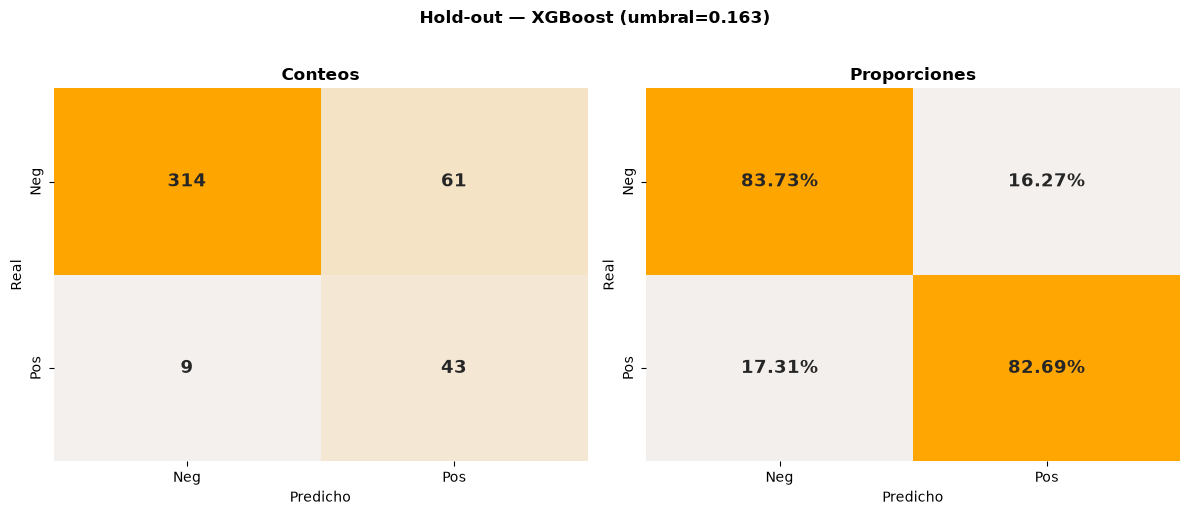

In [27]:
# Matrices de confusión
cm = confusion_matrix(y_test, y_pred_ho)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
color_c = 'orange'
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(color_c, as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title('Conteos', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cbar=False, ax=axes[1],
            cmap=sns.light_palette(color_c, as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[1].set_title('Proporciones', fontweight='bold')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
plt.suptitle(f'Hold-out — {CAMPEON} (umbral={campeon_umbral:.3f})', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/final_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

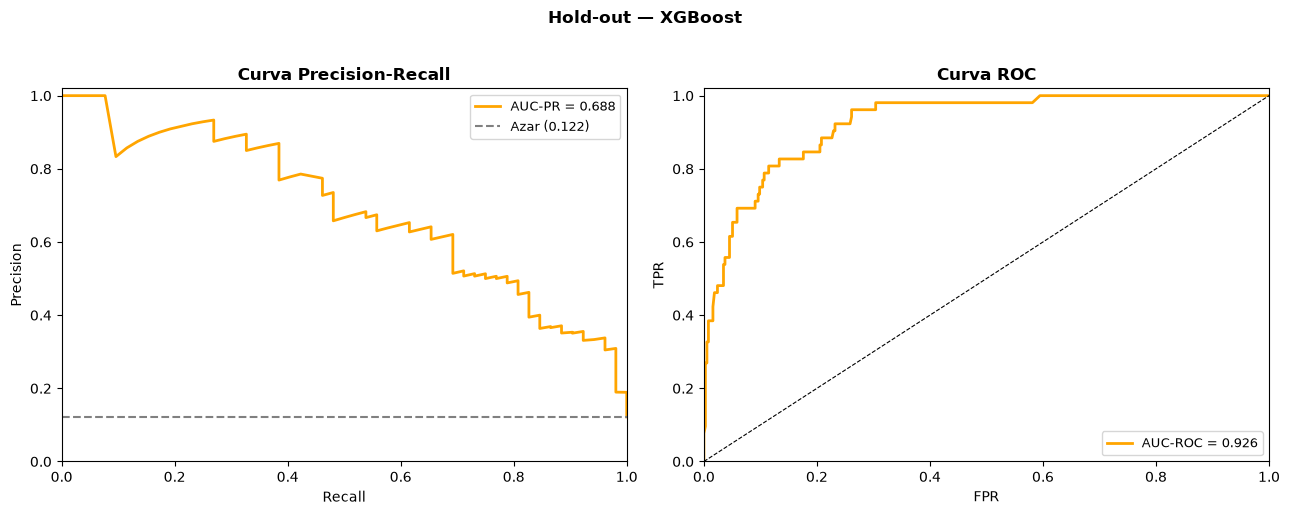

In [28]:
# Curvas PR y ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p, r, _ = precision_recall_curve(y_test, proba_ho)
axes[0].plot(r, p, color=color_c, lw=2, label=f'AUC-PR = {metr_ho["AUC-PR"]:.3f}')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--',
               label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend(fontsize=9)

fpr, tpr, _ = roc_curve(y_test, proba_ho)
axes[1].plot(fpr, tpr, color=color_c, lw=2, label=f'AUC-ROC = {metr_ho["AUC-ROC"]:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(f'Hold-out — {CAMPEON}', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/final_curvas_pr_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Persistencia de artefactos

In [29]:
# ── Guardar modelos calibrados de los 3 ──
modelos_guardados_s3 = {}
for m in TOP_3:
    cfg = TOP3_CONFIG[m]
    sr  = sel_results[m]
    opr = optuna_results[m]
    cr  = cal_results[m]
    Xtr_m = SETS_TR[cfg['set']][sr['set_s3']]
    params_m = opr['params_s3']
    bal_m = cfg['balanceo']
    cal_m = cr['metodo_cal']

    if cal_m == 'Sin calibrar':
        pipe_m = make_pipe(m, params_m, bal_m)
        pipe_m.fit(Xtr_m, y_train)
    else:
        cal_sk = 'sigmoid' if cal_m == 'Sigmoide' else 'isotonic'
        pipe_m = CalibratedClassifierCV(
            make_pipe(m, params_m, bal_m), method=cal_sk, cv=5)
        pipe_m.fit(Xtr_m, y_train)

    slug = m.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path_m = f'{DIR_MODELS}/modelo_calibrado_{slug}.pkl'
    joblib.dump(pipe_m, path_m)
    modelos_guardados_s3[m] = path_m

# ── OOF calibradas (necesarias para stacking en S4) ──
oof_dict = {}
for m in TOP_3:
    oof_dict[m] = cal_results[m]['oof_cal'].tolist()
with open(f'{DIR_DATA}/oof_probas_top3.json', 'w') as f:
    json.dump(oof_dict, f, indent=2)

# ── Features S3 por modelo ──
features_s3 = {m: sel_results[m]['set_s3'] for m in TOP_3}
with open(f'{DIR_DATA}/features_s3_por_modelo.json', 'w') as f:
    json.dump(features_s3, f, indent=2, ensure_ascii=False)

# ── Config campeón ──
config_campeon = {
    'modelo': CAMPEON,
    'familia': TOP3_CONFIG[CAMPEON]['familia'],
    'set_original': TOP3_CONFIG[CAMPEON]['set'],
    'features_s3': campeon_feats,
    'params': campeon_params,
    'balanceo': campeon_bal,
    'calibracion': campeon_cal,
    'umbral': campeon_umbral,
    'umbral_std': cal_results[CAMPEON]['umbral_std'],
    'f2_cv': F2_CAMPEON,
    'f2_oof': cal_results[CAMPEON]['f2_oof'],
}
with open(f'{DIR_DATA}/config_campeon_s3.json', 'w') as f:
    json.dump(config_campeon, f, indent=2, ensure_ascii=False)

print('Artefactos guardados:')
print(f'  Modelos: {list(modelos_guardados_s3.keys())}')
print(f'  OOF probas: {DIR_DATA}/oof_probas_top3.json')
print(f'  Features S3: {DIR_DATA}/features_s3_por_modelo.json')
print(f'  Config campeón: {DIR_DATA}/config_campeon_s3.json')

Artefactos guardados:
  Modelos: ['XGBoost', 'Random Forest', 'SVM (RBF)']
  OOF probas: outputs_sprint3/data/oof_probas_top3.json
  Features S3: outputs_sprint3/data/features_s3_por_modelo.json
  Config campeón: outputs_sprint3/data/config_campeon_s3.json


## Resumen

In [30]:
def _sanitize(obj):
    # Convierte tipos numpy a nativos Python para json.dump
    if isinstance(obj, dict):
        return {_sanitize(k): _sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_sanitize(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

resumen3 = {
    'sprint': 3,
    'nombre': 'SHAP + selección de features + Re-Optuna + calibración + umbral anidado',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': ('Pipeline completo a top-3 por familia; decisión por F2_CV; '
                  'umbral optimizado dentro de cada fold (anidado, criterio max F2); '
                  f'Re-Optuna {N_TRIALS} trials; hold-out una sola vez (informativo).'),
    'metrica_decision': 'f2',
    'campeon': CAMPEON,
    'campeon_familia': TOP3_CONFIG[CAMPEON]['familia'],
    'f2_cv_final': round(F2_CAMPEON, 4),
    'f2_oof_final': round(cal_results[CAMPEON]['f2_oof'], 4),
    'f2_holdout': round(metr_ho['F2'], 4),
    'f2_sprint2': round(F2_SPRINT2, 4),
    'mejora_vs_sprint2': round(F2_CAMPEON - F2_SPRINT2, 4),
    'metricas_holdout': {k: round(v, 4) for k, v in metr_ho.items()},
    'umbral': campeon_umbral,
    'umbral_std': cal_results[CAMPEON]['umbral_std'],
    'calibracion': campeon_cal,
    'top_3': TOP_3,
    'top3_comparativa': resumen_top3,
    'seleccion_features': {m: {'n_s2': len(SETS_TR[TOP3_CONFIG[m]['set']].columns),
                               'n_s3': sel_results[m]['n_opt'],
                               'features': sel_results[m]['set_s3']}
                          for m in TOP_3},
    'optuna_s3': {m: {'f2_cv_s2_fijos': round(optuna_results[m]['f2_fijos'], 4),
                      'f2_cv_optuna': round(optuna_results[m]['f2_optuna'], 4),
                      'origen': optuna_results[m]['origen'],
                      'params': optuna_results[m]['params_s3']}
                 for m in TOP_3},
    'calibracion_detalle': {m: {'metodo': cal_results[m]['metodo_cal'],
                                'brier_uncal': round(cal_results[m]['brier_u'], 4),
                                'brier_sig': round(cal_results[m]['brier_s'], 4),
                                'brier_iso': round(cal_results[m]['brier_i'], 4),
                                'umbral': round(cal_results[m]['umbral'], 4),
                                'umbral_std': round(cal_results[m]['umbral_std'], 4)}
                           for m in TOP_3},
    'learning_curves': {m: {'gap_pre': round(lc_results[m]['gap_pre'], 4),
                            'gap_post': round(lc_results[m]['gap_post'], 4)}
                       for m in TOP_3},
    'ablacion_pathfinders': abl_rows,
    'shap_top5': {m: shap_results[m]['imp_df']['feature'].head(5).tolist()
                 for m in TOP_3},
    'modelos_guardados': modelos_guardados_s3,
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
with open(f'{OUT}/resumen_sprint3.json', 'w') as f:
    json.dump(_sanitize(resumen3), f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 3 ════════════════════')
print(f'Campeón: {CAMPEON} ({TOP3_CONFIG[CAMPEON]["familia"]})')
print(f'  F2_CV   = {F2_CAMPEON:.4f}  (Sprint 2: {F2_SPRINT2:.4f}, Δ = {F2_CAMPEON - F2_SPRINT2:+.4f})')
print(f'  F2_OOF  = {cal_results[CAMPEON]["f2_oof"]:.4f}  (umbral = {campeon_umbral:.3f})')
print(f'  F2 H-O  = {metr_ho["F2"]:.4f}')
print(f'  Features: {sel_results[CAMPEON]["n_opt"]} (SHAP 1-SE)')
print(f'  Calibración: {campeon_cal}')
print(f'  Params: {optuna_results[CAMPEON]["origen"]}')
print(f'\nTop-3 F2_CV:')
for m in TOP_3:
    print(f'  {m:22s}: {optuna_results[m]["f2_s3"]:.4f}  '
          f'({sel_results[m]["n_opt"]} features, {optuna_results[m]["origen"]})')
print(f'\nAblación pathfinders (CAMPEON):')
for _, r in df_abl.iterrows():
    print(f'  {r["Elemento"]:20s}: F2={r["F2_CV"]:.4f} (Δ={r["ΔF2"]:+.4f})')
print(f'\nArtefactos: {OUT}/')
print('Resumen unificado: outputs_sprint3/resumen_sprint3.json')

════════════════════ RESUMEN SPRINT 3 ════════════════════
Campeón: XGBoost (Boosting)
  F2_CV   = 0.7308  (Sprint 2: 0.7258, Δ = +0.0050)
  F2_OOF  = 0.7103  (umbral = 0.163)
  F2 H-O  = 0.6891
  Features: 28 (SHAP 1-SE)
  Calibración: Isotónica
  Params: Optuna S3

Top-3 F2_CV:
  XGBoost               : 0.7308  (28 features, Optuna S3)
  Random Forest         : 0.7026  (39 features, Optuna S3)
  SVM (RBF)             : 0.6764  (8 features, Optuna S3)

Ablación pathfinders (CAMPEON):
  Baseline (todos)    : F2=0.7308 (Δ=+0.0000)
  −As                 : F2=0.7277 (Δ=-0.0031)
  −Sb                 : F2=0.6862 (Δ=-0.0446)
  −Te                 : F2=0.6861 (Δ=-0.0447)
  −Mo                 : F2=0.7397 (Δ=+0.0089)

Artefactos: outputs_sprint3/
Resumen unificado: outputs_sprint3/resumen_sprint3.json
